# 📦 Product Analysis

Products are the primary source of revenue in any retail business.

This section aims to answer:

- Which products generate the highest revenue?
- Which products generate the highest profit?
- Which products generate losses?
- Which sub-categories perform the best?
- Which products require business attention?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

plt.rcParams["figure.figsize"] = (12,6)

In [3]:
df = pd.read_csv('../data/Superstore.csv', encoding="latin1")


In [4]:
product_summary = (

    df.groupby(

        ["Product ID","Product Name","Category","Sub-Category"]

    ).agg(

        Total_Sales=("Sales","sum"),

        Total_Profit=("Profit","sum"),

        Total_Quantity=("Quantity","sum"),

        Orders=("Order ID","nunique"),

        Avg_Discount=("Discount","mean")

    ).sort_values(

        by="Total_Sales",

        ascending=False

    )

)

product_summary.head()

,,,,Total_Sales,Total_Profit,Total_Quantity,Orders,Avg_Discount
Product ID,Product Name,Category,Sub-Category,,,,,
TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,61599.824,2.519993e+04,20,5,0.12
OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,Office Supplies,Binders,27453.384,7.753039e+03,31,10,0.24
TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferencing Unit,Technology,Machines,22638.480,-1.811078e+03,6,1,0.50
FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,Furniture,Chairs,21870.576,5.684342e-14,39,8,0.20
OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,Office Supplies,Binders,19823.479,2.233505e+03,37,11,0.30


In [5]:
product_summary.style.format({

    "Total_Sales":"${:,.2f}",

    "Total_Profit":"${:,.2f}",

    "Avg_Discount":"{:.2%}"

}).background_gradient(cmap="Oranges")

In [6]:
top_sales_products = (

product_summary

.nlargest(10,"Total_Sales")

)

top_sales_products

,,,,Total_Sales,Total_Profit,Total_Quantity,Orders,Avg_Discount
Product ID,Product Name,Category,Sub-Category,,,,,
TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,61599.824,2.519993e+04,20,5,0.120000
OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,Office Supplies,Binders,27453.384,7.753039e+03,31,10,0.240000
TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferencing Unit,Technology,Machines,22638.480,-1.811078e+03,6,1,0.500000
FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,Furniture,Chairs,21870.576,5.684342e-14,39,8,0.200000
OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,Office Supplies,Binders,19823.479,2.233505e+03,37,11,0.300000
OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,Binders,19024.500,7.609800e+02,48,9,0.522222
TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,18839.686,6.983884e+03,38,8,0.200000
TEC-MA-10001127,"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",Technology,Machines,18374.895,4.094977e+03,12,3,0.166667
OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,17965.068,-1.878166e+03,27,6,0.450000


C:\Users\gyanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


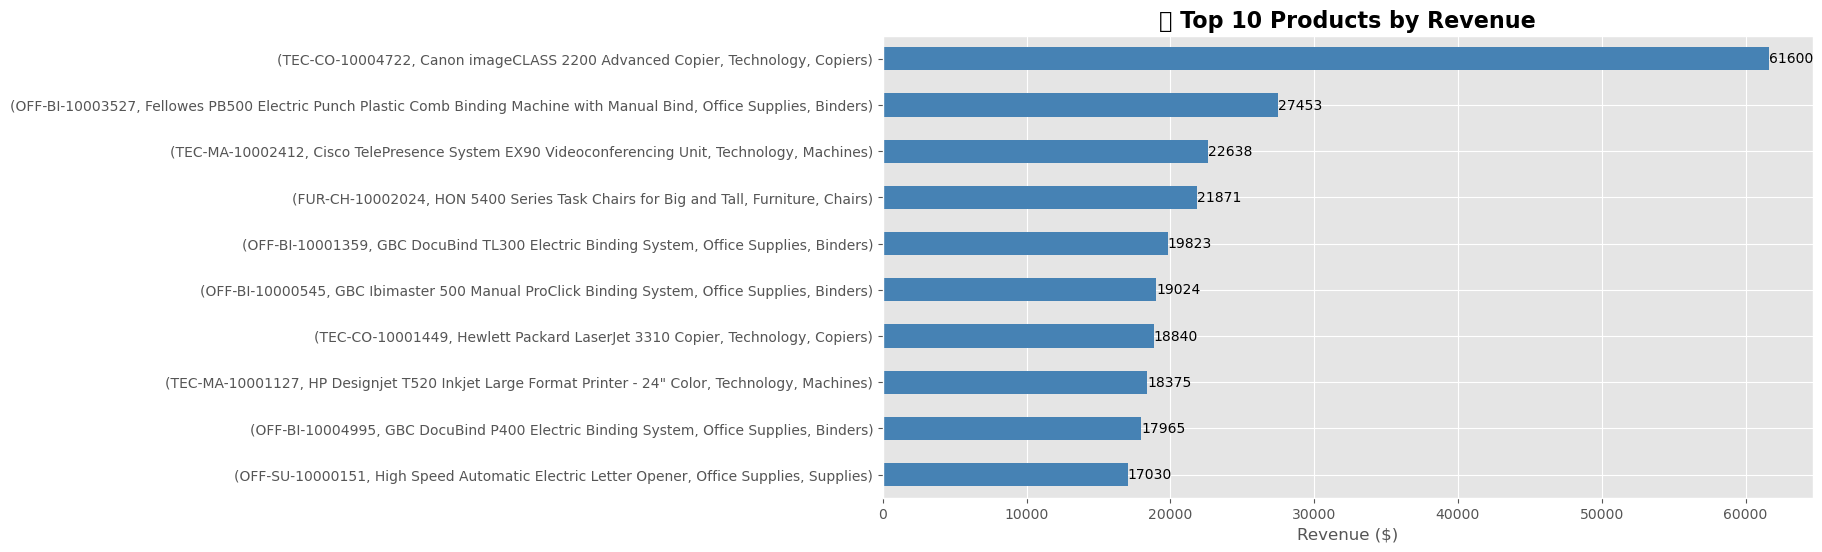

In [7]:
ax = (

top_sales_products

.sort_values("Total_Sales")

["Total_Sales"]

.plot(

kind="barh",

figsize=(12,6),

color="steelblue"

)

)

plt.title(

"🏆 Top 10 Products by Revenue",

fontsize=16,

fontweight="bold"

)

plt.xlabel("Revenue ($)")

plt.ylabel("")

for container in ax.containers:
    ax.bar_label(container,fmt="%.0f")

plt.show()

## 📌 Observation

A limited number of products contribute a disproportionately high share of total revenue.

These products should receive priority in inventory planning, promotions, and stock availability to maximize sales opportunities.

In [8]:
top_profit_products = (

product_summary

.nlargest(

10,

"Total_Profit"

)

)

top_profit_products

,,,,Total_Sales,Total_Profit,Total_Quantity,Orders,Avg_Discount
Product ID,Product Name,Category,Sub-Category,,,,,
TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,61599.824,25199.9280,20,5,0.120000
OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,Office Supplies,Binders,27453.384,7753.0390,31,10,0.240000
TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,18839.686,6983.8836,38,8,0.200000
TEC-CO-10003763,Canon PC1060 Personal Laser Copier,Technology,Copiers,11619.834,4570.9347,19,4,0.150000
TEC-MA-10001127,"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",Technology,Machines,18374.895,4094.9766,12,3,0.166667
TEC-MA-10003979,Ativa V4110MDD Micro-Cut Shredder,Technology,Machines,7699.890,3772.9461,11,2,0.000000
TEC-MA-10001047,"3D Systems Cube Printer, 2nd Generation, Magenta",Technology,Machines,14299.890,3717.9714,11,2,0.000000
TEC-AC-10002049,Plantronics Savi W720 Multi-Device Wireless Headset System,Technology,Accessories,9367.290,3696.2820,24,7,0.057143
OFF-BI-10001120,Ibico EPK-21 Electric Binding System,Office Supplies,Binders,15875.916,3345.2823,13,3,0.333333


C:\Users\gyanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


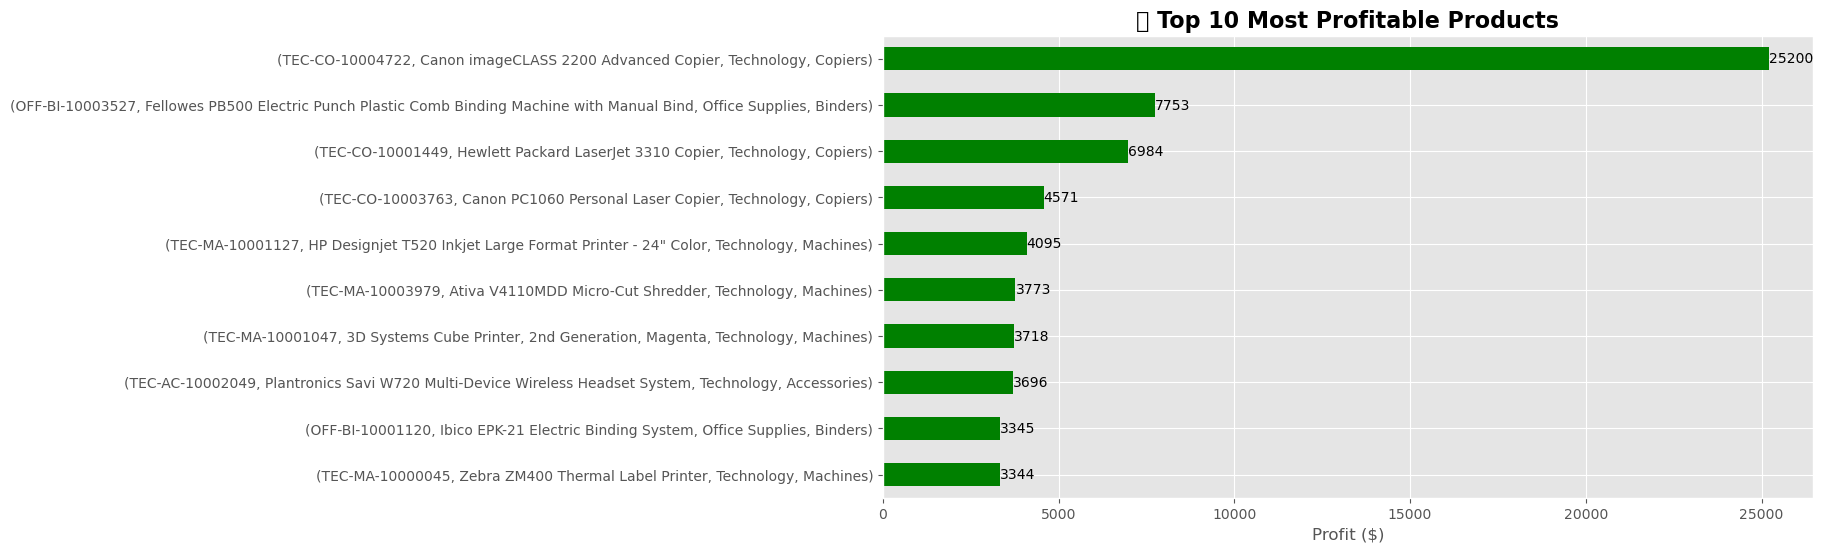

In [9]:
ax=(

top_profit_products

.sort_values("Total_Profit")

["Total_Profit"]

.plot(

kind="barh",

figsize=(12,6),

color="green"

)

)

plt.title(

"💰 Top 10 Most Profitable Products",

fontsize=16,

fontweight="bold"

)

plt.xlabel("Profit ($)")

plt.ylabel("")

for container in ax.containers:
    ax.bar_label(container,fmt="%.0f")

plt.show()

## 📌 Business Insight

High revenue does not necessarily imply high profitability.

Products generating substantial profits should be prioritized for future marketing campaigns due to their stronger financial contribution.

In [11]:
loss_products=(

product_summary

.nsmallest(

10,

"Total_Profit"

)

)

loss_products

,,,,Total_Sales,Total_Profit,Total_Quantity,Orders,Avg_Discount
Product ID,Product Name,Category,Sub-Category,,,,,
TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,11099.963,-8879.9704,9,3,0.533333
TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,16829.901,-4589.9730,18,4,0.400000
TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,Technology,Machines,7999.980,-3839.9904,4,1,0.500000
FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,Furniture,Tables,9917.640,-2876.1156,27,5,0.280000
FUR-TA-10001889,Bush Advantage Collection Racetrack Conference Table,Furniture,Tables,9544.725,-1934.3976,33,7,0.350000
OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,17965.068,-1878.1662,27,6,0.450000
TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferencing Unit,Technology,Machines,22638.480,-1811.0784,6,1,0.500000
OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Opener,Office Supplies,Supplies,16656.200,-1299.1836,22,6,0.100000
FUR-TA-10001950,Balt Solid Wood Round Tables,Furniture,Tables,6518.754,-1201.0581,19,4,0.200000


C:\Users\gyanr\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


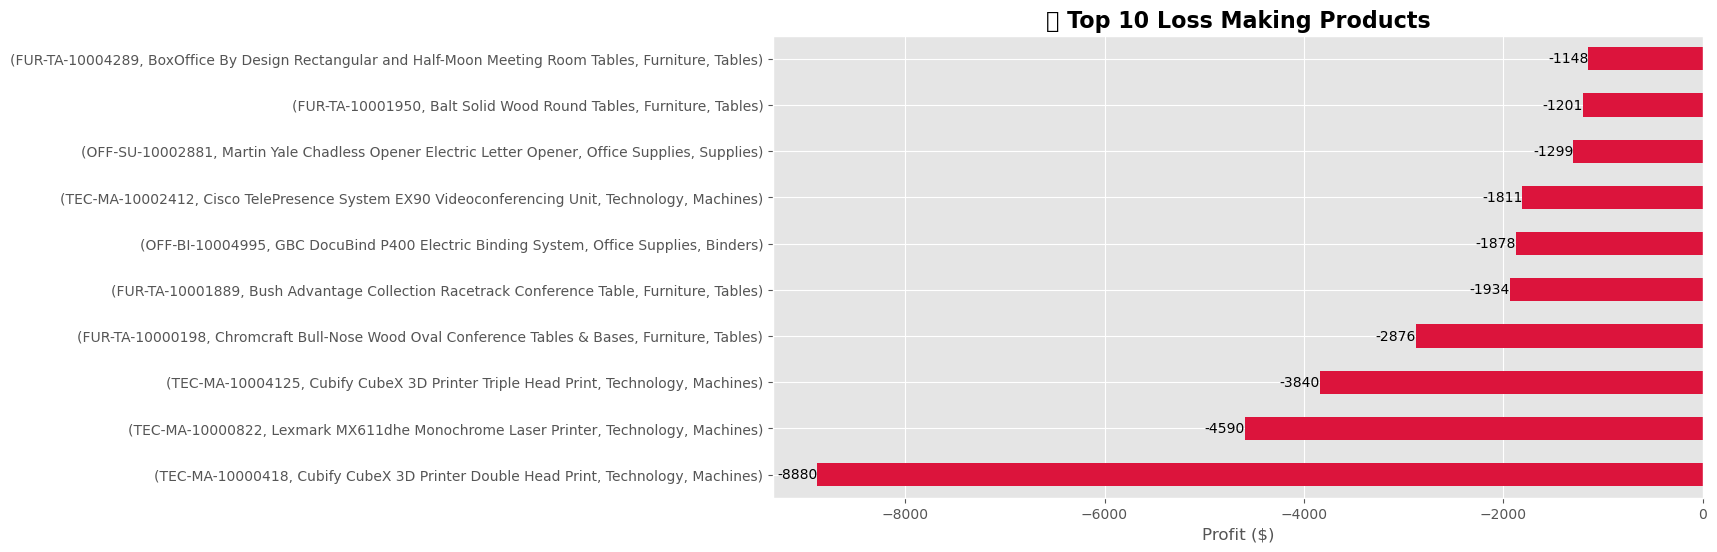

In [12]:
ax=(

loss_products

["Total_Profit"]

.plot(

kind="barh",

figsize=(12,6),

color="crimson"

)

)

plt.title(

"📉 Top 10 Loss Making Products",

fontsize=16,

fontweight="bold"

)

plt.xlabel("Profit ($)")

plt.ylabel("")

for container in ax.containers:
    ax.bar_label(container,fmt="%.0f")

plt.show()

## 📌 Observation

Several products consistently generate financial losses.

Potential causes include:

- Excessive discounts
- Low selling prices
- High operational costs

These products should be reviewed before future procurement decisions.

In [13]:
subcategory_summary=(

df.groupby("Sub-Category")

.agg(

Revenue=("Sales","sum"),

Profit=("Profit","sum"),

Orders=("Order ID","nunique")

)

.sort_values(

"Revenue",

ascending=False

)

)

subcategory_summary

,Revenue,Profit,Orders
Sub-Category,,,
Phones,330007.0540,44515.7306,814
Chairs,328449.1030,26590.1663,576
Storage,223843.6080,21278.8264,777
Tables,206965.5320,-17725.4811,307
Binders,203412.7330,30221.7633,1316
Machines,189238.6310,3384.7569,112
Accessories,167380.3180,41936.6357,718
Copiers,149528.0300,55617.8249,68
Bookcases,114879.9963,-3472.5560,224


In [14]:
subcategory_summary.style.format({

"Revenue":"${:,.2f}",

"Profit":"${:,.2f}"

}).background_gradient(cmap="Purples")

,Revenue,Profit,Orders
Sub-Category,,,
Phones,"$330,007.05","$44,515.73",814
Chairs,"$328,449.10","$26,590.17",576
Storage,"$223,843.61","$21,278.83",777
Tables,"$206,965.53","$-17,725.48",307
Binders,"$203,412.73","$30,221.76",1316
Machines,"$189,238.63","$3,384.76",112
Accessories,"$167,380.32","$41,936.64",718
Copiers,"$149,528.03","$55,617.82",68
Bookcases,"$114,880.00","$-3,472.56",224


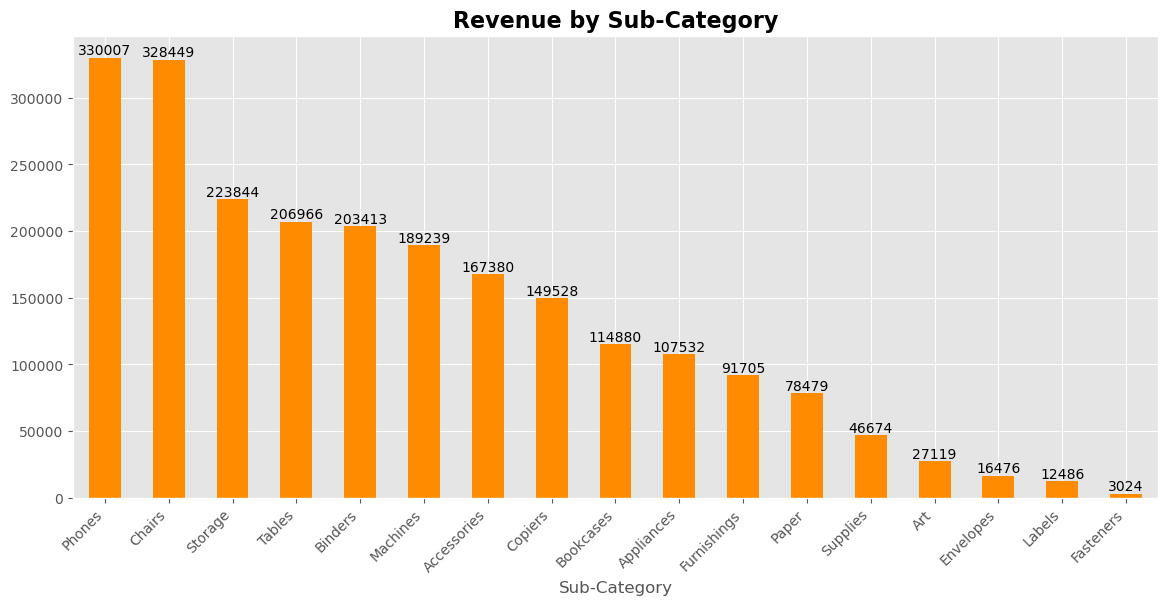

In [15]:
ax=(

subcategory_summary

["Revenue"]

.plot(

kind="bar",

figsize=(14,6),

color="darkorange"

)

)

plt.title(

"Revenue by Sub-Category",

fontsize=16,

fontweight="bold"

)

plt.xticks(rotation=45,ha="right")

for container in ax.containers:
    ax.bar_label(container,fmt="%.0f")

plt.show()

In [17]:
subcategory_summary.sort_values(

"Profit"

).head(10)

,Revenue,Profit,Orders
Sub-Category,,,
Tables,206965.5320,-17725.4811,307
Bookcases,114879.9963,-3472.5560,224
Supplies,46673.5380,-1189.0995,187
Fasteners,3024.2800,949.5182,215
Machines,189238.6310,3384.7569,112
Labels,12486.3120,5546.2540,346
Art,27118.7920,6527.7870,731
Envelopes,16476.4020,6964.1767,249
Furnishings,91705.1640,13059.1436,877


# ✅ Product Analysis Conclusion

Key Findings

- A small number of products account for a significant share of revenue.
- The highest-selling products are not always the most profitable.
- Several products and sub-categories generate losses despite recording sales.
- Business decisions should focus on balancing revenue growth with sustainable profitability.

Recommendation

- Prioritize inventory for high-profit products.
- Investigate pricing and discount policies for loss-making products.
- Monitor underperforming sub-categories to improve margins.